In [3]:
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import scrublet as scr
import h5py
import pandas as pd
from scipy import sparse

In [4]:
m5_adata_egfp_start= ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/m5_adata_egfp_2.h5ad")
p5_1_adata_egfp_start= ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/p5_1_adata_egfp_2.h5ad")
p5_2_adata_egfp_start= ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/p5_2_adata_egfp_2.h5ad")
m4_adata_egfp_start= ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/m4_adata_egfp_2.h5ad")
p4_adata_egfp_start= ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/p4_adata_egfp_2.h5ad")

In [5]:
m5_adata_egfp_start

AnnData object with n_obs × n_vars = 14389 × 28419
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [6]:
m5_adata_egfp= m5_adata_egfp_start.copy()
p5_1_adata_egfp= p5_1_adata_egfp_start.copy()
p5_2_adata_egfp= p5_2_adata_egfp_start.copy()
m4_adata_egfp= m4_adata_egfp_start.copy()
p4_adata_egfp= p4_adata_egfp_start.copy()

In [7]:
adatas = {
    'm5': m5_adata_egfp,
    'p5_1': p5_1_adata_egfp,
    'p5_2': p5_2_adata_egfp,
    'm4': m4_adata_egfp,
    'p4': p4_adata_egfp
    
}

In [8]:
adatas

{'m5': AnnData object with n_obs × n_vars = 14389 × 28419
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
     var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     layers: 'ambiguous', 'matrix', 'spliced', 'unspliced',
 'p5_1': AnnData object with n_obs × n_vars = 14577 × 28419
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
     var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
  

In [9]:
print(p4_adata_egfp.X.shape)
print((p4_adata_egfp[:, "egfp"].X > 0).sum())

(14990, 28419)
60


In [10]:
combined_adata_raw = ad.concat(
    adatas.values(),
    label="sample",
    keys=adatas.keys()
)

In [49]:
combined_adata_raw.write("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/raw/combined_adata_raw_2.h5ad")

In [11]:
combined_adata_raw

AnnData object with n_obs × n_vars = 73845 × 28419
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [12]:
p4_sample = combined_adata_raw[combined_adata_raw.obs["sample"] == "m4"]
print(p4_sample.X.shape)
print((p4_sample[:, "egfp"].X > 0).sum())

(15172, 28419)
1


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


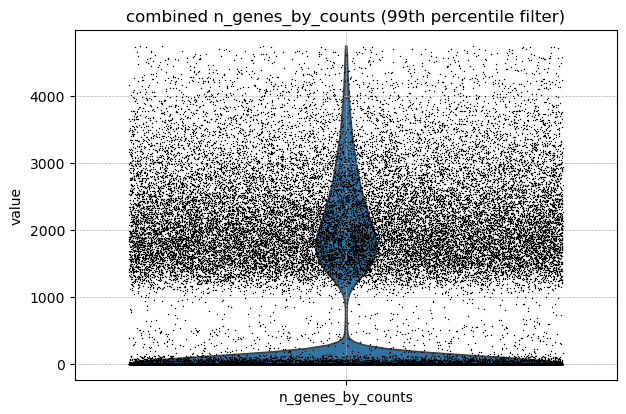

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


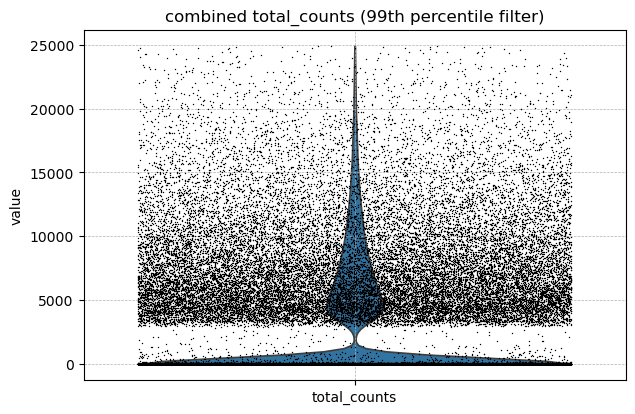

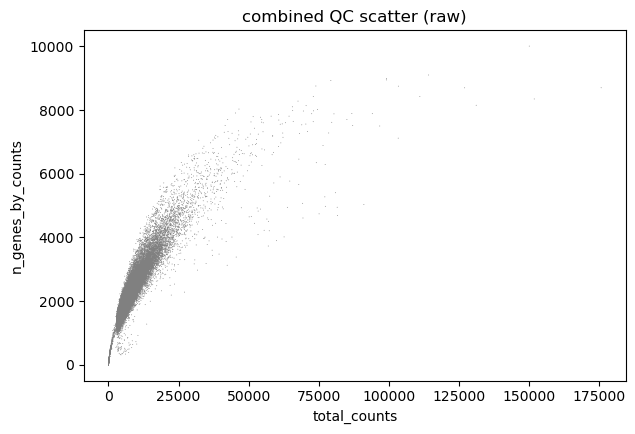

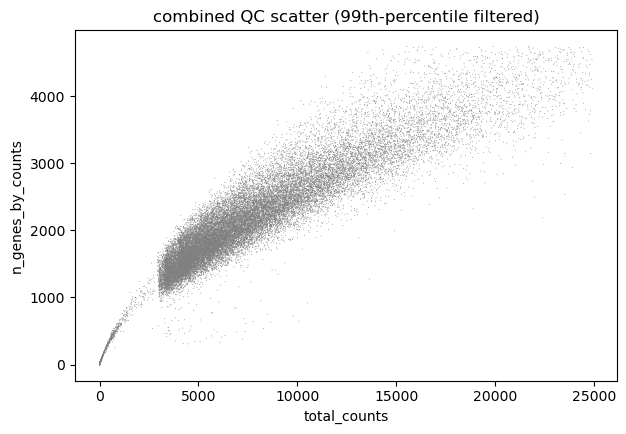

In [13]:
adata = combined_adata_raw.copy()  # single object

# Compute 99th-percentile cutoffs on the combined data
counts_cutoff = np.percentile(adata.obs['total_counts'], 99)
genes_cutoff  = np.percentile(adata.obs['n_genes_by_counts'], 99)

# QC subset (make a copy to avoid view-setting warnings)
adata_qc = adata[
    (adata.obs['total_counts'] < counts_cutoff) &
    (adata.obs['n_genes_by_counts'] < genes_cutoff)
].copy()

# Violin plots on the QC-filtered object
for feature in ['n_genes_by_counts', 'total_counts']:
    sc.pl.violin(
        adata_qc,
        keys=feature,
        jitter=0.4,
        show=False
    )
    plt.title(f"combined {feature} (99th percentile filter)")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

# Scatter (you can plot raw or QC version; here are both)
sc.pl.scatter(
    adata,
    x='total_counts',
    y='n_genes_by_counts',
    show=True,
    title="combined QC scatter (raw)"
)

sc.pl.scatter(
    adata_qc,
    x='total_counts',
    y='n_genes_by_counts',
    show=True,
    title="combined QC scatter (99th-percentile filtered)"
)

In [14]:
sc.pp.filter_cells(combined_adata_raw, min_genes=1000)
sc.pp.filter_cells(combined_adata_raw, max_genes=4000)
combined_adata_raw = combined_adata_raw[combined_adata_raw.obs['total_counts'] < 20000, :] #(Number of UMI per cell)
combined_adata_raw = combined_adata_raw[combined_adata_raw.obs['total_counts'] > 2500, :] #(Number of UMI per cell)
sc.pp.filter_genes(combined_adata_raw, min_cells=3)
sc.pp.highly_variable_genes(combined_adata_raw, flavor="seurat_v3", n_top_genes=2000, subset=True)

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number


In [15]:
p4_sample = combined_adata_raw[combined_adata_raw.obs["sample"] == "m4"]
print(p4_sample.X.shape)
print((p4_sample[:, "egfp"].X > 0).sum())

(5654, 2000)
1


In [16]:
print((combined_adata_raw[:, "egfp"].X > 0).sum())

352


In [18]:
print(combined_adata_raw.obs["sample"].value_counts())

sample
m5      5684
m4      5654
p4      5639
p5_1    5594
p5_2    5497
Name: count, dtype: int64


In [23]:
combined_adata_raw.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,n_genes
CellID,,,,,,,,,,
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAACGCTAGGCGTCCTx,m5,1612,7.385851,5342.0,8.583543,34.481468,50.411831,63.646574,78.060651,1612
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAAGGGCTCCCGATCTx,m5,2840,7.951911,11521.0,9.352014,31.689957,49.327315,61.131846,73.196771,2840
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAACGCTGTCGTCTCTx,m5,3947,8.280964,15229.0,9.631022,28.202771,38.617112,50.587695,64.758027,3947
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAACCCAAGGAACATTx,m5,1866,7.532088,7255.0,8.889584,36.126809,55.286010,67.277739,79.283253,1866
minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D:AAAGGATGTTTCCCACx,m5,2888,7.968666,13345.0,9.498972,31.929562,49.659048,62.143125,74.597227,2888
...,...,...,...,...,...,...,...,...,...,...
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGATCTCGGACTTAx,p4,1687,7.431300,6413.0,8.766238,41.197567,61.484485,70.544207,81.132075,1687
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGACTTCTTCGACCx,p4,2653,7.883823,10989.0,9.304741,35.626536,55.655656,65.975066,75.784876,2653
plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ:TTTGGTTCAAATGGATx,p4,1800,7.496097,5928.0,8.687611,36.740891,55.178812,65.334008,77.311066,1800


In [27]:
import io, numpy as np
from contextlib import redirect_stdout, redirect_stderr
from scipy import sparse
import matplotlib.pyplot as plt

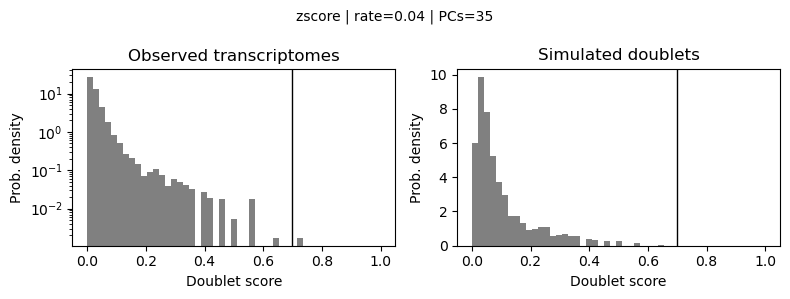

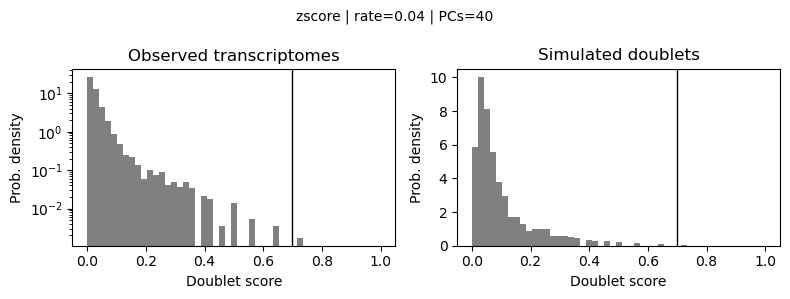

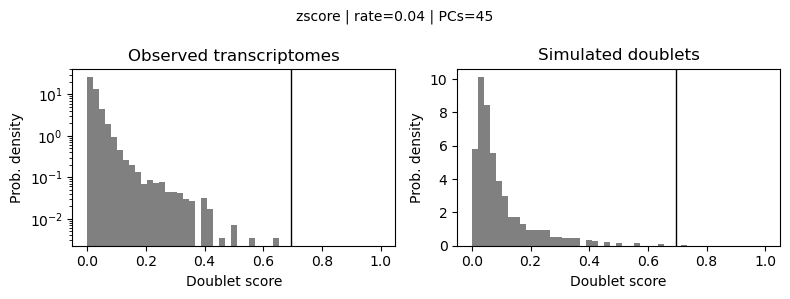

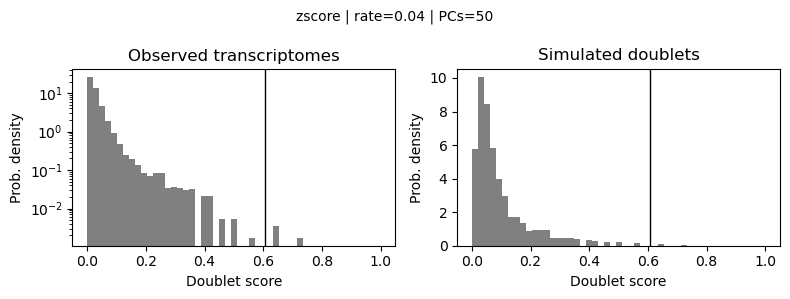

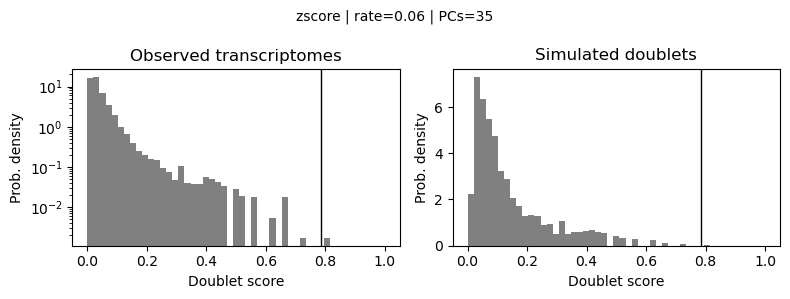

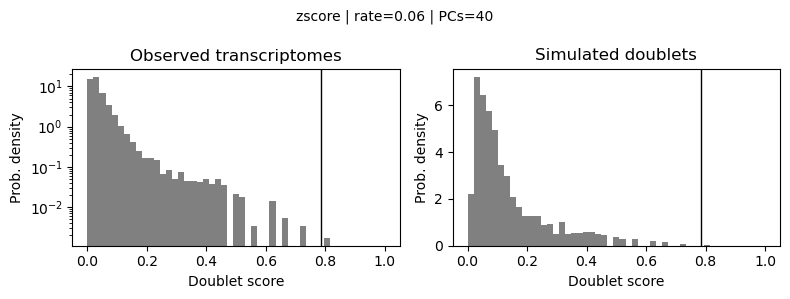

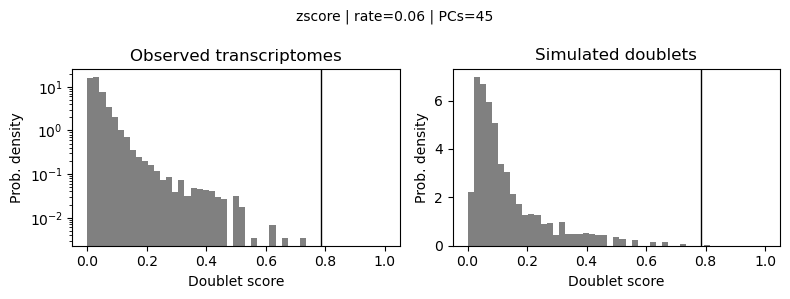

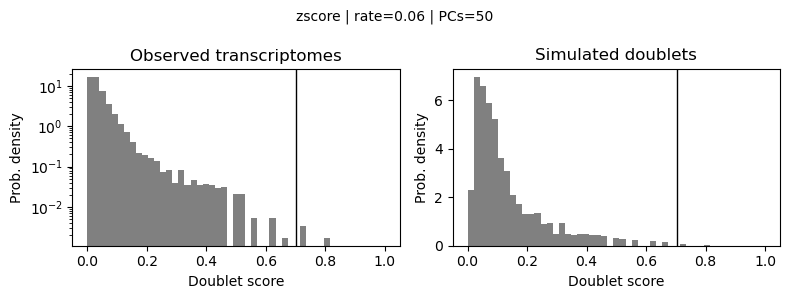

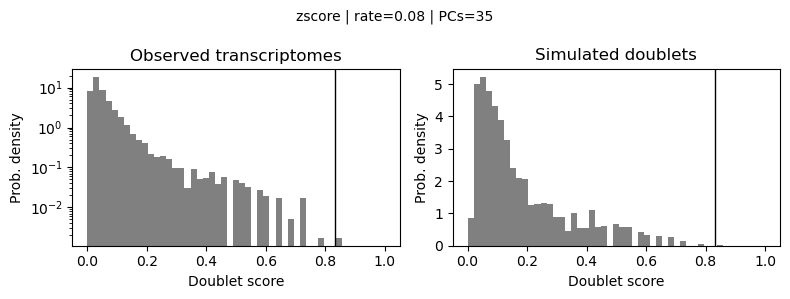

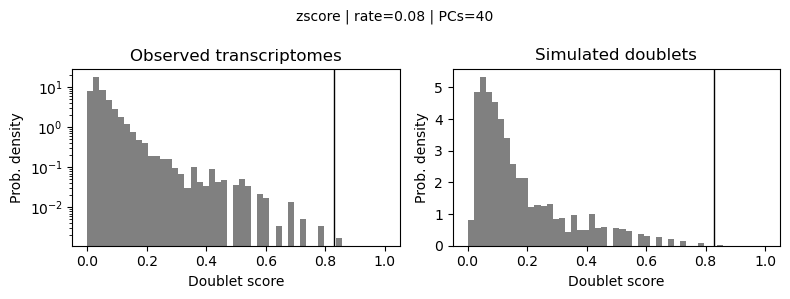

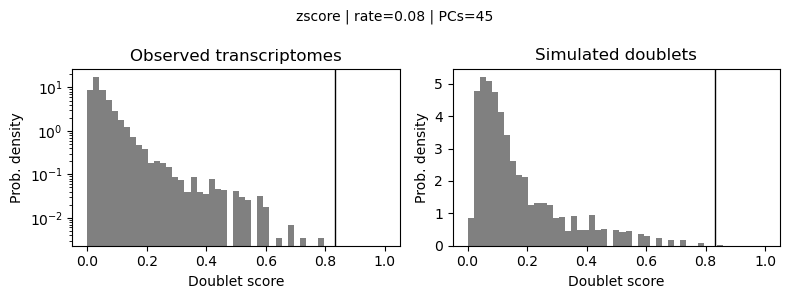

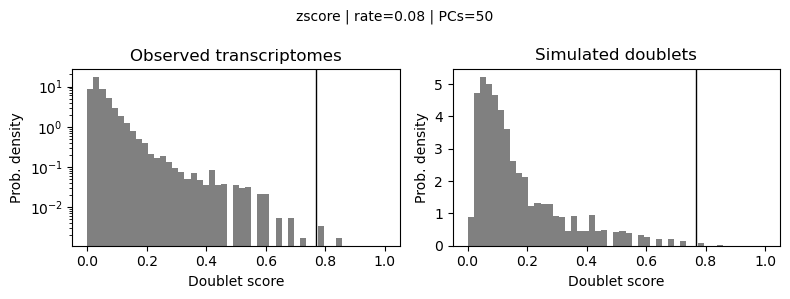

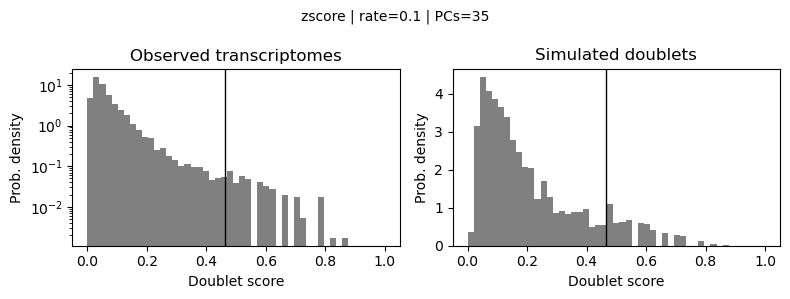

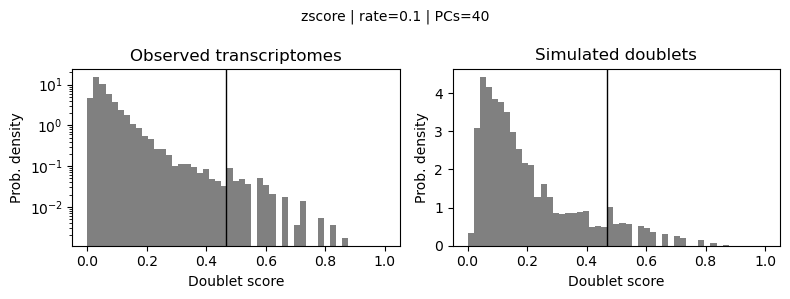

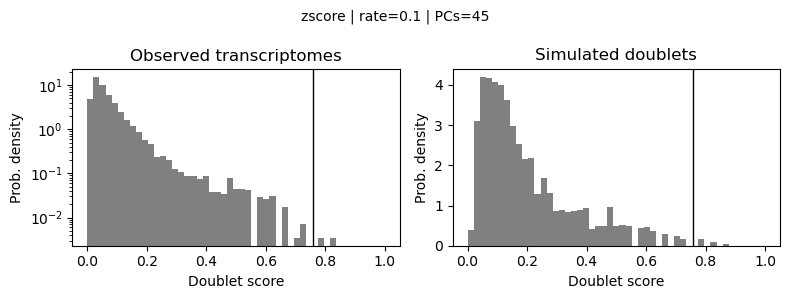

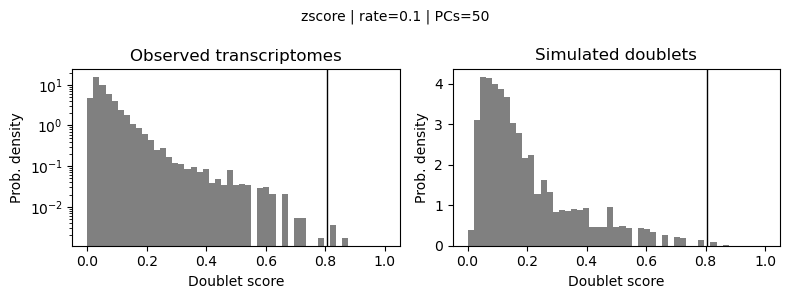

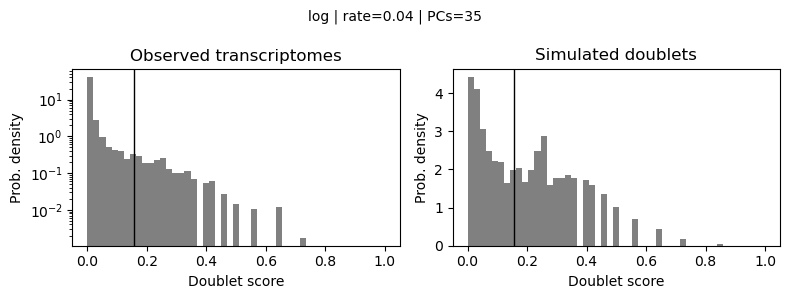

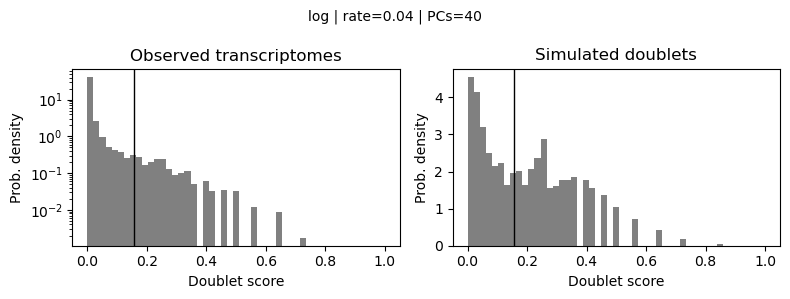

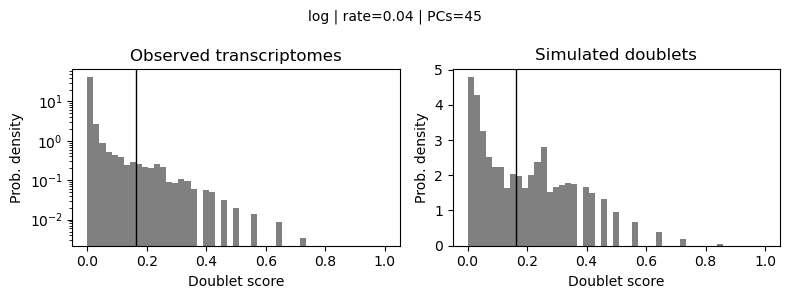

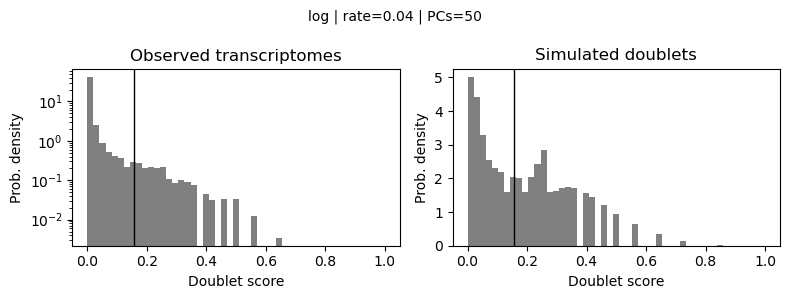

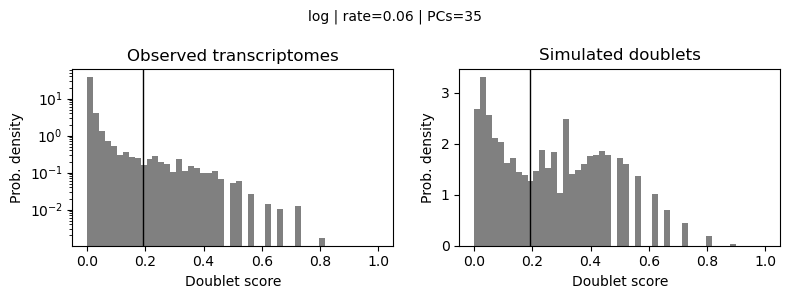

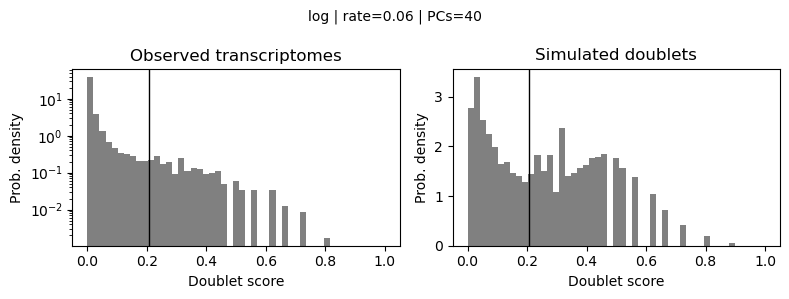

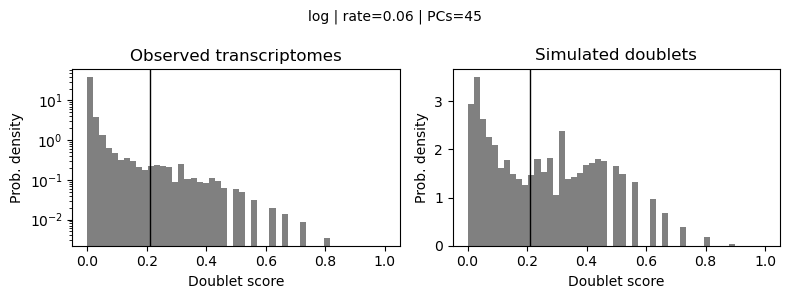

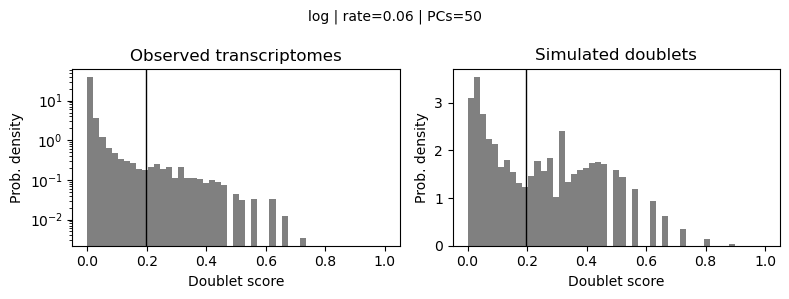

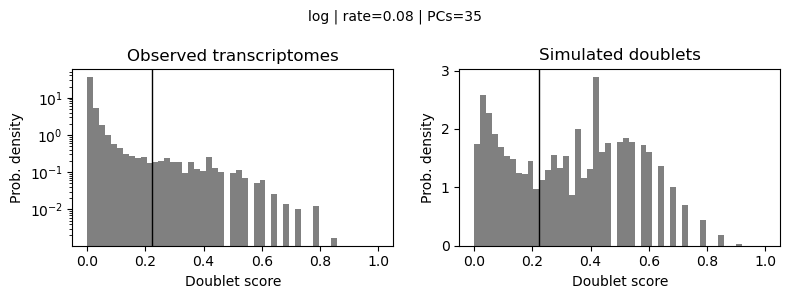

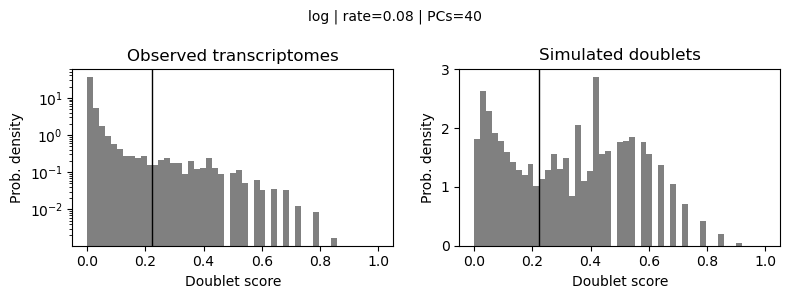

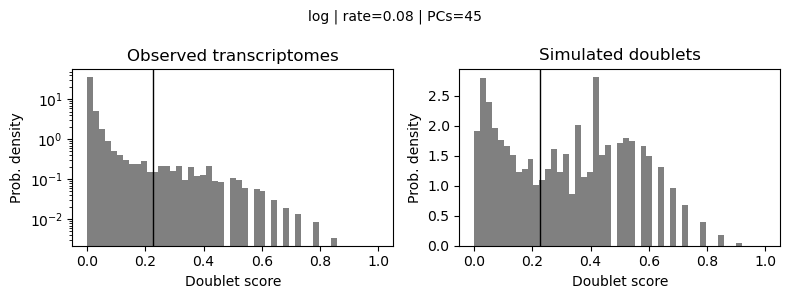

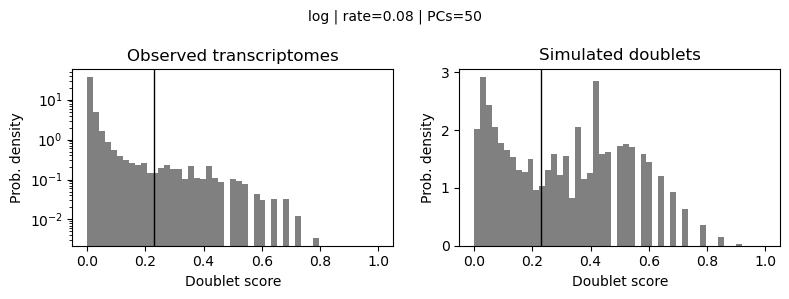

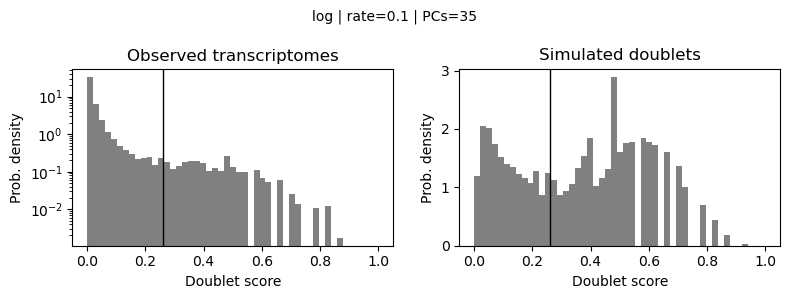

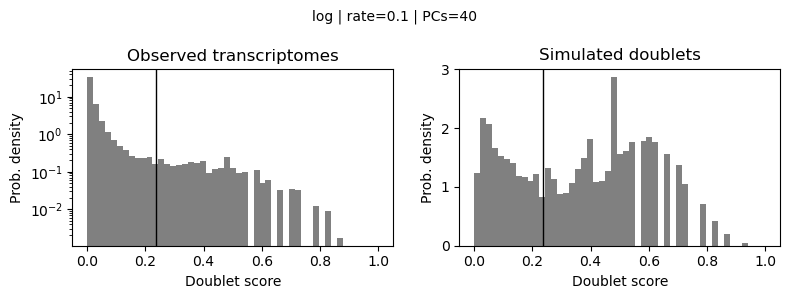

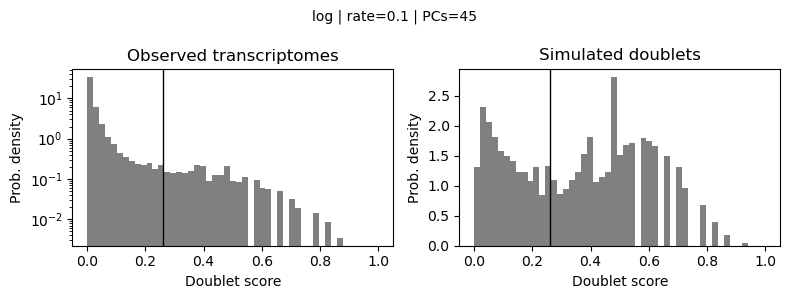

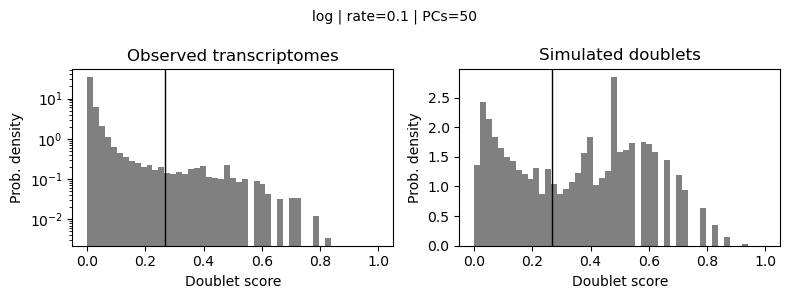

In [29]:
adata = combined_adata_raw
expected_rates = (0.04, 0.06, 0.08, 0.10)
pcs_list       = (35, 40, 45, 50)
methods        = ('zscore', 'log')
seed           = 13
# --------------

M = adata.X if sparse.isspmatrix_csr(adata.X) else adata.X.tocsr()
np.random.seed(seed)

for method in methods:
    for rate in expected_rates:
        for pcs in pcs_list:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                scrub = scr.Scrublet(M, expected_doublet_rate=rate)
                scores, preds = scrub.scrub_doublets(
                    n_prin_comps=pcs,
                    mean_center=(method == 'zscore'),
                    normalize_variance=(method == 'zscore'),
                    log_transform=(method == 'log')
                )

            # Let Scrublet create its own two-panel figure (observed + simulated)
            scrub.plot_histogram()

            # Add a concise descriptor to that figure
            fig = plt.gcf()
            fig.suptitle(f"{method} | rate={rate} | PCs={pcs}", y=0.98, fontsize=10)
            fig.tight_layout()
            plt.show()

In [36]:
import io, numpy as np
from contextlib import redirect_stdout, redirect_stderr
from scipy import sparse
import matplotlib.pyplot as plt
# import scrublet as scr  # if not already imported

adata = combined_adata_raw                 # .X must be raw counts
expected_rate = 0.04                      # pick your rate
log_transform = True                      # or True if you want log mode
pcs = 50
threshold = .4                           # or e.g., 0.25 for manual

# Use CSR counts (Scrublet handles CSR efficiently)
M = adata.X if sparse.isspmatrix_csr(adata.X) else adata.X.tocsr()

with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    scrub = scr.Scrublet(M, expected_doublet_rate=expected_rate)
    scores, preds = scrub.scrub_doublets(
        n_prin_comps=pcs,
        mean_center=(not log_transform),
        normalize_variance=(not log_transform),
        log_transform=log_transform,
    )

if threshold is not None:
    scrub.call_doublets(threshold=threshold)
    preds = scrub.predicted_doublets_

# Save to obs
adata.obs['doublet_score']    = scores
adata.obs['predicted_doublet'] = preds.astype(bool)

combined_adata_scrubbed = adata[~adata.obs['predicted_doublet']].copy()

Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 9.7%
Overall doublet rate:
	Expected   = 4.0%
	Estimated  = 2.4%


In [35]:
print(combined_adata_raw.obs["sample"].value_counts())

sample
m5      5684
m4      5654
p4      5639
p5_1    5594
p5_2    5497
Name: count, dtype: int64


In [37]:
print(combined_adata_scrubbed.obs["sample"].value_counts())

sample
m5      5675
m4      5649
p4      5634
p5_1    5563
p5_2    5482
Name: count, dtype: int64


In [48]:
p4_sample = combined_adata_scrubbed[combined_adata_scrubbed.obs["sample"] == "m4"]
print(p4_sample.X.shape)
print((p4_sample[:, "egfp"].X > 0).sum())

(5649, 2000)
1


In [106]:
adatas_clean

{'m5': AnnData object with n_obs × n_vars = 5780 × 2000
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet'
     var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: 'hvg'
     layers: 'ambiguous', 'matrix', 'spliced', 'unspliced',
 'p5_1': AnnData object with n_obs × n_vars = 5805 × 2000
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 

In [49]:
combined_adata_scrubbed.write("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/combined_adata_scrubleted_egfp.h5ad")